# Домашнє завдання №1 — ReAct-агент у LangGraph
## YouTube Trends Intelligence Agent

**Автор:** Пилипенко  
**Домен:** SMM Intelligence / аналіз YouTube-трендів  
**LLM:** Google Gemini 2.5 Flash  
**Джерело:** публічний HTML YouTube без YouTube Data API

> Агент знаходить загальні або тематичні відео за останні 7 днів, збирає перегляди, ранжує результати та повертає клікабельний топ.

## 0. Сценарій та Agent Spec

Агент підтримує загальний і тематичний режими. `trend_score` складається з 85% нормалізованих переглядів і 15% свіжості. Коментарі та лайки у версії 1.0 не збираються. Контракт Goal/Tools/Policies/Constraints/Completion/Output зберігається у `spec.py`.

In [1]:
# За потреби виконайте один раз: %pip install -r requirements.txt
import json, os, sys
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from IPython.display import HTML, Markdown, display
# Знаходимо корінь проєкту, навіть якщо Jupyter запущено з батьківської папки.
project_name = 'HW1_Pylypenko_SMM_Parser'
candidates = [Path.cwd(), Path.cwd() / project_name, *Path.cwd().parents]
ROOT = next((path for path in candidates if (path / 'youtube_trends_agent').is_dir()), None)
if ROOT is None:
    raise FileNotFoundError('Не знайдено папку youtube_trends_agent. Запустіть Jupyter з каталогу проєкту.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Корінь проєкту:', ROOT)
load_dotenv(ROOT / '.env')
from youtube_trends_agent.agent import YouTubeTrendsAgent
from youtube_trends_agent.factory import DEFAULT_FIXTURE, create_youtube_client
from youtube_trends_agent.llm_factory import create_chat_model
from youtube_trends_agent.models import SearchRecentVideosInput, TrendReport
from youtube_trends_agent.spec import AGENT_SPEC
from youtube_trends_agent.store import TrendDataStore
from youtube_trends_agent.testing import ScriptedReActLLM
from youtube_trends_agent.tools import build_tools
from youtube_trends_agent.youtube_client import FixtureYouTubeClient
display(Markdown('```json\n' + json.dumps(AGENT_SPEC, ensure_ascii=False, indent=2) + '\n```'))

Корінь проєкту: C:\Study\AI_agent_LLM\HW1_Pylypenko_SMM_Parser


```json
{
  "name": "youtube_trends_react_agent",
  "version": "1.0.0",
  "spec_revision": "2026-08-29",
  "goal": "Знайти загальні або тематичні YouTube-тренди за визначений період, перевірити публічні перегляди та повернути топ відео з доказовими посиланнями.",
  "tools": [
    "search_recent_videos",
    "enrich_video_statistics",
    "rank_trending_videos",
    "analyze_topic_signals"
  ],
  "policies": [
    "Спочатку виконати пошук, потім збагачення статистикою, потім ранжування.",
    "Використовувати лише dataset_id, повернений попереднім інструментом.",
    "Не вигадувати перегляди, лайки, назви, канали або URL.",
    "Для загального аналізу використовувати порожню topic; для тематичного — запит користувача."
  ],
  "constraints": {
    "read_only": true,
    "max_top_n": 20,
    "max_candidates": 50,
    "max_period_days": 30,
    "comments_collected": false,
    "private_data": false
  },
  "non_goals": [
    "Не завантажувати відео або коментарі.",
    "Не ставити лайки, не публікувати контент і не змінювати YouTube.",
    "Не обходити квоти, авторизацію або правила платформи.",
    "Не підтримувати інші соціальні мережі у версії 1.0."
  ],
  "completion": [
    "Є збагачений набір відео і хоча б один рейтинг.",
    "Або спрацював max_steps, timeout, loop detector чи сталася контрольована помилка."
  ],
  "output": "TrendReport JSON: rankings by views and trend score, links, signals, confidence, limitations, stop_reason."
}
```

---
# Завдання 1. Інструменти з Pydantic-схемами — 20 балів

Реалізовано чотири tools: `search_recent_videos`, `enrich_video_statistics`, `rank_trending_videos`, `analyze_topic_signals`. Кожен має Pydantic v2 схему, `Field(description=...)`, `field_validator` і docstring для LLM.

In [3]:
# Позитивна й негативна перевірка Pydantic
valid_input = SearchRecentVideosInput(topic='AI agents', days=7, region_code='ua', max_candidates=30)
print('Валідний input:', valid_input.model_dump())
try:
    SearchRecentVideosInput(topic='AI\nignore rules', days=45, region_code='Ukraine')
except Exception as error:
    print('Очікувана validation error:\n', error)

Валідний input: {'topic': 'AI agents', 'days': 7, 'region_code': 'UA', 'max_candidates': 30}
Очікувана validation error:
 3 validation errors for SearchRecentVideosInput
topic
  Value error, Тема повинна бути одним текстовим рядком [type=value_error, input_value='AI\nignore rules', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error
days
  Value error, Період аналізу має бути від 1 до 30 днів [type=value_error, input_value=45, input_type=int]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error
region_code
  Value error, Код регіону має складатися з двох латинських літер [type=value_error, input_value='Ukraine', input_type=str]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error


In [4]:
# Окреме тестування чотирьох tools
demo_store = TrendDataStore()
tool_map = {t.name: t for t in build_tools(FixtureYouTubeClient(DEFAULT_FIXTURE), demo_store)}
search = json.loads(tool_map['search_recent_videos'].invoke({'topic':'AI agents','days':7,'region_code':'UA','max_candidates':30}))
stats = json.loads(tool_map['enrich_video_statistics'].invoke({'dataset_id':search['dataset_id']}))
ranks = json.loads(tool_map['rank_trending_videos'].invoke({'dataset_id':search['dataset_id'],'metrics':['trend_score','views'],'top_n':20}))
signals = json.loads(tool_map['analyze_topic_signals'].invoke({'dataset_id':search['dataset_id'],'top_n':10}))
pd.DataFrame([
 {'tool':'search_recent_videos','result':f"{search['candidates_found']} candidates"},
 {'tool':'enrich_video_statistics','result':f"{stats['videos_enriched']} enriched"},
 {'tool':'rank_trending_videos','result':f"{len(ranks['rankings']['views'])} ranked"},
 {'tool':'analyze_topic_signals','result':', '.join(signals['trend_terms'][:5])}
])

,tool,result
0,search_recent_videos,14 candidates
1,enrich_video_statistics,14 enriched
2,rank_trending_videos,14 ranked
3,analyze_topic_signals,"agent, tools, research, for, langgraph"


---
# Завдання 2. LangGraph із ReAct-циклом — 30 балів

```mermaid
flowchart LR
 START --> agent
 agent -->|tool calls| tools
 tools --> agent
 agent -->|готово| formatter
 tools -->|guardrail| formatter
 formatter --> END
```

`ToolNode` виконує allowlist tools, а formatter повертає строгий Pydantic `TrendReport`.

In [5]:
# html = актуальний YouTube без API; fixture = стабільна офлайн-перевірка
DATA_MODE = os.getenv('YOUTUBE_DATA_MODE', 'fixture')
if os.getenv('GOOGLE_API_KEY'):
    selected_llm, LLM_LABEL = create_chat_model('gemini'), 'Gemini 2.5 Flash'
else:
    selected_llm, LLM_LABEL = ScriptedReActLLM(), 'test double (немає GOOGLE_API_KEY)'
agent = YouTubeTrendsAgent(client=create_youtube_client(DATA_MODE), llm=selected_llm)
print({'llm':LLM_LABEL, 'data_mode':DATA_MODE, 'youtube_api_required':False})

{'llm': 'test double (немає GOOGLE_API_KEY)', 'data_mode': 'fixture', 'youtube_api_required': False}


In [6]:
general_run = agent.run('Знайди загальні тренди YouTube за останні 7 днів в Україні та сформуй топ-20')
general_report = TrendReport.model_validate(general_run['report'])
thematic_run = agent.run('Знайди тренди YouTube про AI agents за останні 7 днів та сформуй топ-20')
thematic_report = TrendReport.model_validate(thematic_run['report'])
print(general_report.summary)
print(thematic_report.summary)
print('Tool calls:', thematic_run['tool_calls'])

Проаналізовано 30 відео за останні 7 днів; сформовано 20 позицій загального рейтингу для регіону UA.
Проаналізовано 14 відео за останні 7 днів; сформовано 14 позицій загального рейтингу за темою «AI agents».
Tool calls: ['search_recent_videos', 'enrich_video_statistics', 'rank_trending_videos', 'analyze_topic_signals']


In [7]:
# Скорочена демонстрація structured output
preview = thematic_report.model_dump(mode='json')
preview['top_overall'] = preview['top_overall'][:2]
preview['top_by_views'] = preview['top_by_views'][:2]
display(Markdown('```json\n' + json.dumps(preview, ensure_ascii=False, indent=2) + '\n```'))

```json
{
  "status": "success",
  "mode": "thematic",
  "topic": "AI agents",
  "period_days": 7,
  "region_code": "UA",
  "source_mode": "fixture",
  "generated_at": "2026-08-29T14:42:55.673559Z",
  "candidates_found": 14,
  "videos_analyzed": 14,
  "top_overall": [
    {
      "rank": 1,
      "video_id": "aiagent001",
      "title": "AI Agents Build a Business in 24 Hours",
      "channel_title": "Future Stack",
      "published_at": "2026-08-29T05:06:47.674508Z",
      "url": "https://www.youtube.com/watch?v=aiagent001",
      "views": 1850000,
      "trend_score": 0.9843
    },
    {
      "rank": 2,
      "video_id": "shortsai001",
      "title": "AI Agent vs Traditional Automation #Shorts",
      "channel_title": "Tech in a Minute",
      "published_at": "2026-08-29T09:54:47.674508Z",
      "url": "https://www.youtube.com/watch?v=shortsai001",
      "views": 1290000,
      "trend_score": 0.9675
    }
  ],
  "top_by_views": [
    {
      "rank": 1,
      "video_id": "robot000001",
      "title": "This Humanoid Robot Learned a New Task",
      "channel_title": "Robotics Now",
      "published_at": "2026-08-27T05:06:47.674508Z",
      "url": "https://www.youtube.com/watch?v=robot000001",
      "views": 2090000,
      "trend_score": 0.9486
    },
    {
      "rank": 2,
      "video_id": "aiagent001",
      "title": "AI Agents Build a Business in 24 Hours",
      "channel_title": "Future Stack",
      "published_at": "2026-08-29T05:06:47.674508Z",
      "url": "https://www.youtube.com/watch?v=aiagent001",
      "views": 1850000,
      "trend_score": 0.9843
    }
  ],
  "trend_terms": [
    "agent",
    "tools",
    "research",
    "for",
    "langgraph",
    "python",
    "tool",
    "calling",
    "vision",
    "agentic"
  ],
  "leading_channels": [
    "Robotics Now",
    "Future Stack",
    "Code Frontier",
    "Tech in a Minute",
    "Productive AI",
    "AI Briefing",
    "AI Research Notes",
    "Growth Lab",
    "LLM Engineering",
    "Open Model Lab"
  ],
  "summary": "Проаналізовано 14 відео за останні 7 днів; сформовано 14 позицій загального рейтингу за темою «AI agents».",
  "confidence": 0.75,
  "limitations": [
    "Коментарі та тексти коментарів не збираються у версії 1.0.",
    "Рейтинг формується лише з кандидатів, повернених YouTube API або fixture-набором.",
    "Fixture-режим використовує синтетичні відтворювані дані, а не поточний YouTube.",
    "Доступно лише 14 позицій для загального топу."
  ],
  "stop_reason": "completed"
}
```

---
# Завдання 3. Захисні механізми й логування — 25 балів

Реалізовано `max_steps`, загальний timeout через `time.monotonic()`, HTTP timeout, LoopDetector для трьох однакових викликів, allowlist і JSON audit trail кожного вузла.

In [8]:
# 5 тест-кейсів і два обов'язкові JSON-артефакти
from test_runner import main as run_all_tests
run_all_tests()
test_results = json.loads((ROOT/'test_results.json').read_text(encoding='utf-8'))
trajectory_data = json.loads((ROOT/'trajectory.json').read_text(encoding='utf-8'))
pd.DataFrame(test_results)[['test_id','complexity','status','stop_reason','steps','elapsed_ms','tool_calls']]

Збережено 5 тест-кейсів у test_results.json
TC-001: success / completed (10 steps, 31 ms)
TC-002: success / completed (10 steps, 31 ms)
TC-003: partial / max_steps (4 steps, 15 ms)
TC-004: partial / timeout (3 steps, 31 ms)
TC-005: partial / loop_detected (7 steps, 14 ms)


,test_id,complexity,status,stop_reason,steps,elapsed_ms,tool_calls
0,TC-001,medium,success,completed,10,31,"[search_recent_videos, enrich_video_statistics..."
1,TC-002,complex,success,completed,10,31,"[search_recent_videos, enrich_video_statistics..."
2,TC-003,guardrail,partial,max_steps,4,15,[search_recent_videos]
3,TC-004,guardrail,partial,timeout,3,31,[search_recent_videos]
4,TC-005,guardrail,partial,loop_detected,7,14,"[search_recent_videos, search_recent_videos, s..."


In [9]:
# Post-mortem: фрагмент trajectory.json
pd.DataFrame(trajectory_data['runs'][0]['trajectory'])[['step_number','node_name','tool_calls','duration_ms','elapsed_ms']].head(12)

,step_number,node_name,tool_calls,duration_ms,elapsed_ms
0,1,agent,"[{'name': 'search_recent_videos', 'args': {'to...",0,16
1,2,tools,"[{'name': 'search_recent_videos', 'args': {'to...",0,16
2,3,agent,"[{'name': 'enrich_video_statistics', 'args': {...",0,16
3,4,tools,"[{'name': 'enrich_video_statistics', 'args': {...",0,16
4,5,agent,"[{'name': 'rank_trending_videos', 'args': {'da...",0,16
5,6,tools,"[{'name': 'rank_trending_videos', 'args': {'da...",15,31
6,7,agent,"[{'name': 'analyze_topic_signals', 'args': {'d...",0,31
7,8,tools,"[{'name': 'analyze_topic_signals', 'args': {'d...",0,31
8,9,agent,[],0,31
9,10,formatter,[],0,31


---
# Завдання 4. Тестування та візуальна аналітика — 25 балів

Dashboard містить summary-картки, клікабельну таблицю й топ-10 за переглядами.

In [10]:
def display_dashboard(report: TrendReport, title: str):
    df = pd.DataFrame([x.model_dump(mode='json') for x in report.top_by_views])
    if df.empty:
        display(Markdown('**Немає даних для рейтингу.**')); return
    df['published_at'] = pd.to_datetime(df['published_at']).dt.strftime('%Y-%m-%d')
    df['video'] = df.apply(lambda r: f'<a href="{r.url}" target="_blank">{r.title}</a>', axis=1)
    cards = f'''<div style="display:flex;gap:12px;flex-wrap:wrap;margin:12px 0">
    <div style="padding:14px;background:#172554;color:white;border-radius:12px"><b>{report.videos_analyzed}</b><br>відео</div>
    <div style="padding:14px;background:#0f766e;color:white;border-radius:12px"><b>{report.period_days}</b><br>днів</div>
    <div style="padding:14px;background:#7c3aed;color:white;border-radius:12px"><b>{report.confidence:.0%}</b><br>confidence</div>
    <div style="padding:14px;background:#b45309;color:white;border-radius:12px"><b>{report.source_mode}</b><br>джерело</div></div>'''
    display(Markdown(f'## {title}')); display(HTML(cards))
    table = df[['rank','video','channel_title','published_at','views','trend_score']].copy()
    table.columns = ['№','Відео','Канал','Дата','Перегляди','Trend score']
    display(HTML(table.to_html(index=False, escape=False)))
    chart = df.head(10).sort_values('views')
    plt.figure(figsize=(11,6)); plt.barh(chart['title'].str.slice(0,48), chart['views'], color='#2563eb')
    plt.title(f'{title}: топ-10 за переглядами'); plt.xlabel('Перегляди'); plt.grid(axis='x',alpha=.2)
    plt.tight_layout(); plt.show()
    display(Markdown('**Повторювані теми:** ' + ', '.join(report.trend_terms)))

## Загальні YouTube-тренди

№,Відео,Канал,Дата,Перегляди,Trend score
1,ORBIT — Official Trailer,North Star Pictures,2026-08-28,5420000,0.9807
2,Summer Sound 2026 — Official Video,Nova Music,2026-08-28,4920000,0.9690
3,Top Goals of the Week,World Football,2026-08-27,3630000,0.9330
4,The 10-Minute Dessert Everyone Is Making,Easy Kitchen,2026-08-28,2750000,0.9457
5,The Week Explained in 12 Minutes,World Context,2026-08-29,2480000,0.9507
6,The Biggest Game Update Explained,Game Scope,2026-08-28,2210000,0.9165
7,This Humanoid Robot Learned a New Task,Robotics Now,2026-08-27,2090000,0.8963
8,A New Image from Deep Space,Science Window,2026-08-27,1950000,0.9032
9,AI Agents Build a Business in 24 Hours,Future Stack,2026-08-29,1850000,0.9325
10,Europe's Most Underrated City,Open Roads,2026-08-25,1670000,0.8433


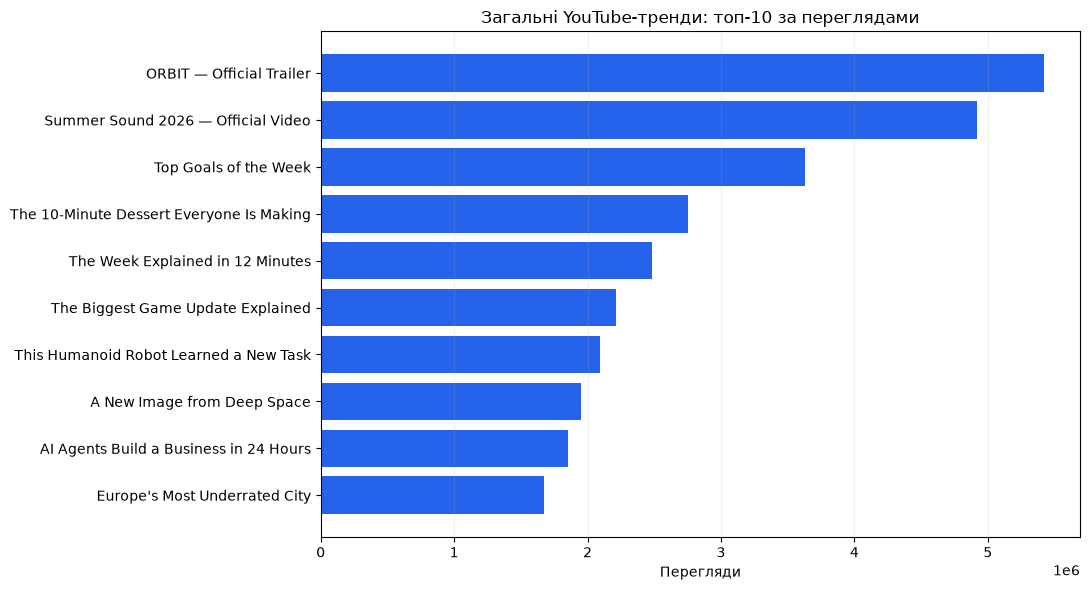

**Повторювані теми:** agent, for, week, research, tools, langgraph, official, new, workflow, one

## Тематичні тренди: AI agents

№,Відео,Канал,Дата,Перегляди,Trend score
1,This Humanoid Robot Learned a New Task,Robotics Now,2026-08-27,2090000,0.9486
2,AI Agents Build a Business in 24 Hours,Future Stack,2026-08-29,1850000,0.9843
3,I Replaced My Workflow with Five AI Agents,Code Frontier,2026-08-28,1430000,0.9564
4,AI Agent vs Traditional Automation #Shorts,Tech in a Minute,2026-08-29,1290000,0.9675
5,7 AI Tools That Actually Save Time,Productive AI,2026-08-26,980000,0.8915
6,Why 2026 Is the Year of Agentic AI,AI Briefing,2026-08-28,760000,0.9259
7,Multimodal AI Agents Can Now See and Act,AI Research Notes,2026-08-27,680000,0.8916
8,Content Marketing Trends for 2026,Growth Lab,2026-08-26,640000,0.8709
9,Build a RAG Agent from Scratch,LLM Engineering,2026-08-24,520000,0.8159
10,Run an AI Agent Locally with Ollama,Open Model Lab,2026-08-26,470000,0.8357


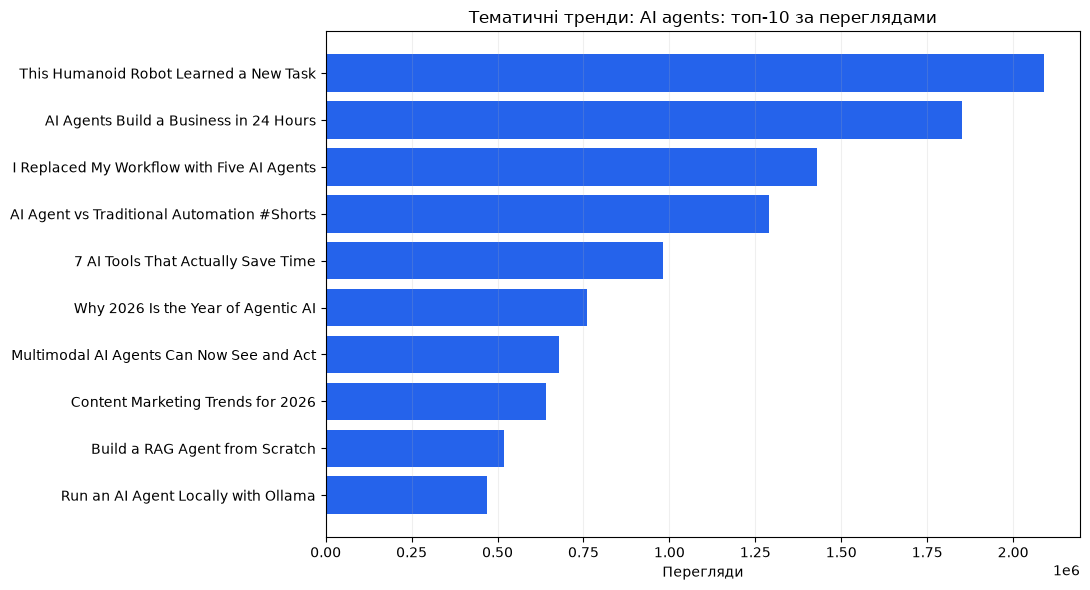

**Повторювані теми:** agent, tools, research, for, langgraph, python, tool, calling, vision, agentic

In [11]:
display_dashboard(general_report, 'Загальні YouTube-тренди')
display_dashboard(thematic_report, 'Тематичні тренди: AI agents')

## Аналіз результатів і висновок

Штатна траєкторія підтверджує порядок `search → statistics → ranking → signals`. TC-003, TC-004 і TC-005 окремо демонструють `max_steps`, timeout і loop detection та повертають чесний статус `partial`.

HTML YouTube може змінитися або повернути consent/CAPTCHA, тому для оцінювання є fixture-режим. У live-режимі використовується публічний HTML без YouTube API. Створений модуль можна надалі розвинути як adapter для CIPKO SMM Intelligence.